# Thử nghiệm kiến trúc mô hình ANN

Notebook này thử nghiệm các **kiến trúc mạng khác nhau** (số tầng ẩn, số nơ-ron) để quan sát ảnh hưởng tới hiệu năng, phục vụ phần lựa chọn mô hình.

> **Lưu ý:** nếu đang dùng dữ liệu mẫu (`data/heart.csv` giả lập), các con số chỉ minh hoạ cách chạy. Số liệu cho báo cáo phải lấy từ dữ liệu thật của nhóm.

## 1. Import thư viện và nạp dữ liệu

In [7]:
import warnings, os, sys
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # giảm log nhiễu của TensorFlow

# Thêm thư mục src/ vào đường dẫn để import được model.py và data_loader.py
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

from model import build_model
from data_loader import load_data

# Cố định seed để kết quả lặp lại được
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow', tf.__version__)

TensorFlow 2.21.0


In [8]:
# Nạp dữ liệu (đường dẫn '../data' vì notebook nằm trong thư mục notebook/)
X_train, X_test, y_train, y_test = load_data('../data/heart.csv', target_column='target')
input_dim = X_train.shape[1]
input_dim

So dac trung dau vao (input_dim): 13
Kich thuoc tap train: 736 mau
Kich thuoc tap test : 184 mau


13

## 2. Định nghĩa các kiến trúc cần thử

Thử từ mạng nông (ít tầng) đến mạng sâu hơn để xem kiến trúc nào phù hợp nhất với dữ liệu dạng bảng của bài toán.

In [9]:
architectures = [
    {'name': '1 tang an',  'hidden': (32,)},
    {'name': '2 tang an',  'hidden': (64, 32)},
    {'name': '3 tang an',  'hidden': (64, 32, 16)},
    {'name': '4 tang an',  'hidden': (128, 64, 32, 16)},
]

# Cấu hình huấn luyện chung cho mọi kiến trúc (chỉ đổi kiến trúc, giữ nguyên phần còn lại)
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 100

## 3. Huấn luyện từng kiến trúc và lưu lịch sử

In [10]:
histories = {}
results = []

for arch in architectures:
    print(f"\n>>> Dang huan luyen: {arch['name']} - {arch['hidden']}")
    tf.random.set_seed(42)

    model = build_model(input_dim=input_dim,
                        hidden_units=arch['hidden'],
                        learning_rate=LEARNING_RATE)

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True)

    hist = model.fit(X_train, y_train,
                     validation_split=0.2,
                     epochs=EPOCHS, batch_size=BATCH_SIZE,
                     callbacks=[early_stop], verbose=0)
    histories[arch['name']] = hist

    # Đánh giá trên tập test
    res = dict(zip(model.metrics_names, model.evaluate(X_test, y_test, verbose=0)))
    acc = res.get('compile_metrics', res.get('accuracy'))
    results.append({'Kien truc': arch['name'],
                    'Hidden': '-'.join(map(str, arch['hidden'])),
                    'Test Loss': round(res['loss'], 4),
                    'Test Accuracy': round(acc, 4),
                    'So epoch': len(hist.history['loss'])})

print('\nXong tat ca!')


>>> Dang huan luyen: 1 tang an - (32,)

>>> Dang huan luyen: 2 tang an - (64, 32)

>>> Dang huan luyen: 3 tang an - (64, 32, 16)

>>> Dang huan luyen: 4 tang an - (128, 64, 32, 16)

Xong tat ca!


## 4. Bảng tổng hợp kết quả

In [11]:
df_results = pd.DataFrame(results)
df_results

,Kien truc,Hidden,Test Loss,Test Accuracy,So epoch
0,1 tang an,32,0.4397,0.8098,37
1,2 tang an,64-32,0.4239,0.7989,20
2,3 tang an,64-32-16,0.4467,0.8207,20
3,4 tang an,128-64-32-16,0.4754,0.8261,18


## 5. Biểu đồ so sánh đường học (validation loss)

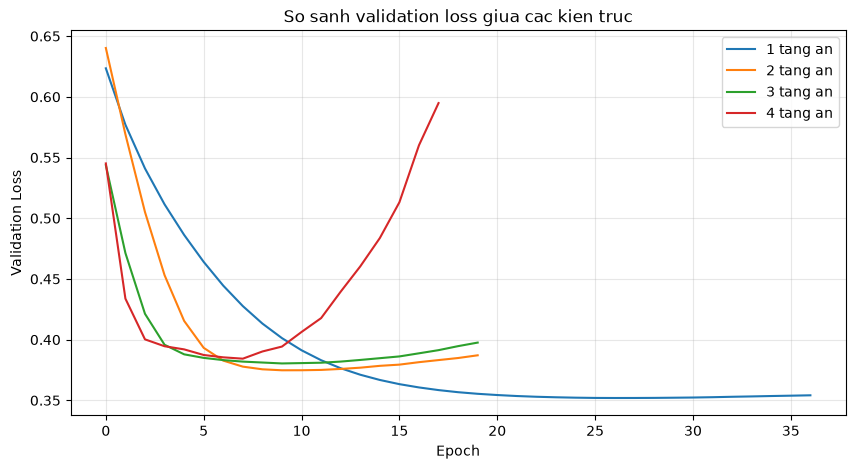

In [12]:
plt.figure(figsize=(10, 5))
for name, hist in histories.items():
    plt.plot(hist.history['val_loss'], label=name)
plt.title('So sanh validation loss giua cac kien truc')
plt.xlabel('Epoch'); plt.ylabel('Validation Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## 6. Nhận xét

_(Điền nhận xét sau khi chạy với dữ liệu thật.)_ Thông thường:
- Mạng quá nông có thể chưa học đủ (underfitting).
- Mạng quá sâu trên dữ liệu bảng nhỏ dễ overfitting và lâu hội tụ.
- Kiến trúc 2–3 tầng ẩn thường cân bằng tốt cho bài toán này.